     shots,    errors,  discards, seconds,decoder,strong_id,json_metadata,custom_counts
    913681,      1001,         0,   0.718,pymatching,011a9563e996d90de73ed886b856d3a5c3995517b58b5c8d29e559058a835069,"{""d"":3,""p"":0.002}",
   1000000,       326,         0,    3.19,pymatching,cee8ea72ed8492105d6b3911f22bf24e45623aa6017b6dd94659d7bd4b37d40f,"{""d"":5,""p"":0.002}",
   1000000,        72,         0,    8.81,pymatching,101e2cba582c41ec51886cd048c54ce0abc0909c0843d279e02f1dc6f1b64eaf,"{""d"":7,""p"":0.002}",
   1000000,        20,         0,    21.7,pymatching,133a3c273e20c721d9eb17cfa9274a7bd78dbe3ec32e2dcd0620dafafaa777c4,"{""d"":9,""p"":0.002}",
    463121,      1001,         0,   0.374,pymatching,35cb2e28b05658bea7267325bb6c82f48ee5fb9a93461f61e846bbc8b40c1b02,"{""d"":3,""p"":0.002979591836734694}",
    981265,      1000,         0,    3.99,pymatching,60de7d516fdc9f526244a80ccbf6fc8bd441892198e28e8da89fbf17470b4918,"{""d"":5,""p"":0.002979591836734694}",
   1000000,       374,  

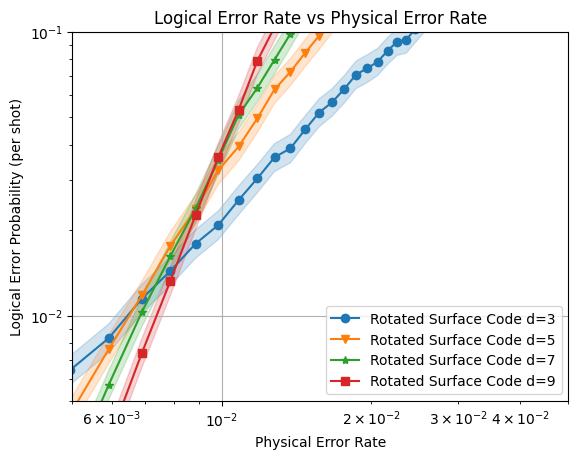

In [1]:
import stim
import sinter
import matplotlib.pyplot as plt
import numpy as np

# generate surface code circuit tasks 
def generate_example_tasks():
    #logrange = np.logspace(-4,-1,50)
    linrange = np.linspace(0.002, 0.05, 50)
    for p in linrange:
        for d in [3, 5,7,9]:
            yield sinter.Task(
                circuit=stim.Circuit.generated(
                    rounds=d,
                    distance=d,
                    after_clifford_depolarization=p,
                    code_task=f'surface_code:rotated_memory_x',
                ),
                json_metadata={
                    'p': p,
                    'd': d,
                },
            )

samples = sinter.collect(
    num_workers=4,
    max_shots=1_000_000,
    max_errors=1000,
    tasks=generate_example_tasks(),
    decoders=['pymatching'],
)


print(sinter.CSV_HEADER)
for sample in samples:
    print(sample.to_csv_line())


fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=samples,
    group_func=lambda stat: f"Rotated Surface Code d={stat.json_metadata['d']}",
    x_func=lambda stat: stat.json_metadata['p'],
)
ax.loglog()
ax.set_ylim(5e-3, 1e-1)
ax.set_xlim(5e-3,5e-2)
ax.grid()
ax.set_title('Logical Error Rate vs Physical Error Rate')
ax.set_ylabel('Logical Error Probability (per shot)')
ax.set_xlabel('Physical Error Rate')
ax.legend()

#fig.savefig('plot.png')
plt.show()




--- Sweeping for Optimal Crossing Point (0.006 to 0.008) ---

--- Sweep Complete ---
Optimal Data Window Centered At: 0.007966
Calculated p^x_th (Cross):       0.0094773 ± 0.0003134
Calculated v_0 (Crit Exp):       1.02364


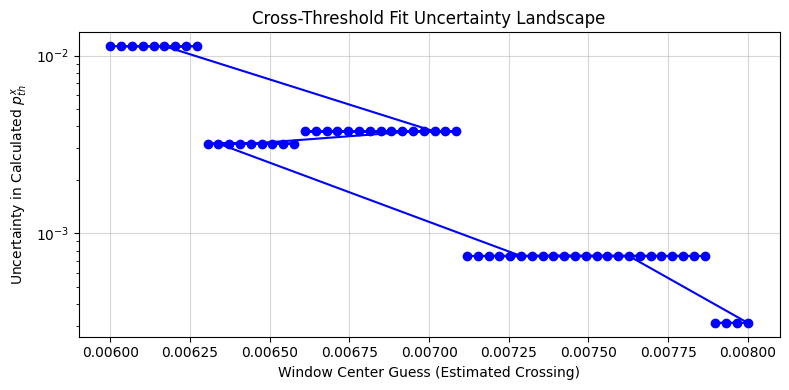

In [2]:
# searching for best crossing point
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import warnings
from scipy.optimize import OptimizeWarning

def cross_threshold_model(data, A, B, C, p_th_cross, v_0):
    p, d = data
    x = (p - p_th_cross) * (d ** (1 / v_0))
    return A + B * x + C * (x ** 2)

def log_scaling_threshold_model(data, log_c, p_th_star, alpha):
    p, d = data
    exponent = alpha * ((d + 1) / 2)
    # log(p_L) = log(c) + alpha * ((d+1)/2) * log(p / p_th_star)
    return log_c + exponent * np.log(p / p_th_star)
    
def find_best_crossing_point(samples, min_guess=0.003, max_guess=0.008, steps=50, min_d=7):
    """
    Sweeps through potential crossing points to find the fit with the lowest uncertainty.
    """
    print(f"\n--- Sweeping for Optimal Crossing Point ({min_guess} to {max_guess}) ---")

    ps = np.array([s.json_metadata['p'] for s in samples])
    ds = np.array([s.json_metadata['d'] for s in samples])
    shots = np.array([max(s.shots, 1) for s in samples])
    errors = np.array([s.errors for s in samples])
    
    y = errors / shots
    y_err = np.sqrt(y * (1.0 - y) / shots)
    zero_mask = y == 0
    y[zero_mask] = 1.0 / shots[zero_mask] 
    y_err[zero_mask] = 1.0 / shots[zero_mask]

    guesses = np.linspace(min_guess, max_guess, steps)
    results = []


    with warnings.catch_warnings():
        warnings.simplefilter("ignore", OptimizeWarning)
        
        for guess in guesses:
            lower_bound = guess * 0.75
            upper_bound = guess * 1.25
            
            near_p_mask = (ps >= lower_bound) & (ps <= upper_bound) & (ds >= min_d)
            
            if np.sum(near_p_mask) >= 6:
                approx_A = np.mean(y[near_p_mask]) 
                p0_cross = [approx_A, 10.0, 10.0, guess, 1.0] 
                
                bounds_cross = (
                    [0.0, -np.inf, -np.inf, 0.001, 0.1], 
                    [1.0,  np.inf,  np.inf, 0.05,  5.0]  
                )
                
                try:
                    popt_cross, pcov_cross = curve_fit(
                        cross_threshold_model, 
                        (ps[near_p_mask], ds[near_p_mask]), y[near_p_mask], 
                        p0=p0_cross, bounds=bounds_cross, maxfev=10000,
                        sigma=y_err[near_p_mask], absolute_sigma=True 
                    )
                    
                    perr_cross = np.sqrt(np.diag(pcov_cross))
                    p_th_uncertainty = perr_cross[3]
                    calculated_p_th = popt_cross[3]
                    
                    # (Guess, Calculated Threshold, Uncertainty, Full popt)
                    results.append((guess, calculated_p_th, p_th_uncertainty, popt_cross))
                    
                except RuntimeError:
                    pass 

    if not results:
        print("Error: No valid fits found across the entire sweep range.")
        return None
        
    results.sort(key=lambda x: x[2])
    best_result = results[0]
    
    print("\n--- Sweep Complete ---")
    print(f"Optimal Data Window Centered At: {best_result[0]:.6f}")
    print(f"Calculated p^x_th (Cross):       {best_result[1]:.7f} ± {best_result[2]:.7f}")
    print(f"Calculated v_0 (Crit Exp):       {best_result[3][4]:.5f}")
    

    _plot_error_landscape(results)
    
    return best_result[3] 

def _plot_error_landscape(results):
    guesses = [r[0] for r in results]
    uncertainties = [r[2] for r in results]
    
    plt.figure(figsize=(8, 4))
    plt.plot(guesses, uncertainties, marker='o', linestyle='-', color='b')
    plt.title("Cross-Threshold Fit Uncertainty Landscape")
    plt.xlabel("Window Center Guess (Estimated Crossing)")
    plt.ylabel("Uncertainty in Calculated $p^x_{th}$")
    plt.yscale('log')
    plt.grid(True, alpha=0.5)
    plt.tight_layout()
    #plt.savefig("sweep_landscape.png")


best_cross_params = find_best_crossing_point(
    samples, 
    min_guess=0.006, 
    max_guess=0.008, 
    steps=60,        
    min_d=7   
)

In [3]:
def calculate_robust_thresholds(samples, estimated_crossing: float = 0.006, min_d: int = 7):

    ps = np.array([s.json_metadata['p'] for s in samples])
    ds = np.array([s.json_metadata['d'] for s in samples])
    shots = np.array([max(s.shots, 1) for s in samples])
    errors = np.array([s.errors for s in samples])
    
    y = errors / shots
    
    y_err = np.sqrt(y * (1.0 - y) / shots)
    zero_mask = y == 0
    y[zero_mask] = 1.0 / shots[zero_mask] 
    y_err[zero_mask] = 1.0 / shots[zero_mask]

    popt_scale, popt_cross = None, None
    
    print("\n--- Calculating Scaling Threshold ---")
    
    scale_cutoff = estimated_crossing * 0.6
    scale_mask = (ps <= scale_cutoff) & (ds >= min_d)
    
    if np.sum(scale_mask) >= 3:
        log_y = np.log(y[scale_mask])
        log_y_err = y_err[scale_mask] / y[scale_mask] 
        
        # p0: [ln(c), p_th, alpha]
        p0_scale = [np.log(0.5), estimated_crossing, 1.0] 
        
        bounds_scale = ([-np.inf, 0.0001, 0.1], [10.0, 0.05, 10.0])
        
        try:
            popt_scale_log, pcov_scale = curve_fit(
                log_scaling_threshold_model, 
                (ps[scale_mask], ds[scale_mask]), log_y, 
                p0=p0_scale, bounds=bounds_scale, maxfev=20000,
                sigma=log_y_err, absolute_sigma=True
            )
            perr_scale = np.sqrt(np.diag(pcov_scale))
            
            c_val = np.exp(popt_scale_log[0])
            print(f"p*_th (Scaling): {popt_scale_log[1]:.7f} ± {perr_scale[1]:.7f}")
            print(f"c = {c_val:.5f}")
            print(f"alpha = {popt_scale_log[2]:.5f} +/- {perr_scale[2]:.5f}")
        except Exception as e:
            print(f"Scaling Fit failed: {e}")

    print("\n--- Calculating Cross Threshold ---")
    
    # Use a +/- 25% window around the estimated crossing
    lower_bound = estimated_crossing * 0.75
    upper_bound = estimated_crossing * 1.25
    
    near_p_mask = (ps >= lower_bound) & (ps <= upper_bound) & (ds >= min_d)
    num_cross_points = np.sum(near_p_mask)
    
    print(f"Using {num_cross_points} data points for cross-threshold fit...")
    
    if num_cross_points >= 6: 
        approx_A = np.mean(y[near_p_mask]) 
        p0_cross = [approx_A, 10.0, 10.0, estimated_crossing, 1.0] 
        
        bounds_cross = (
            [0.0, -np.inf, -np.inf, 0.001, 0.1], 
            [1.0,  np.inf,  np.inf, 0.05,  5.0]  
        )
        try:
            popt_cross, pcov_cross = curve_fit(
                cross_threshold_model, 
                (ps[near_p_mask], ds[near_p_mask]), y[near_p_mask], 
                p0=p0_cross, bounds=bounds_cross, maxfev=20000,
                sigma=y_err[near_p_mask], absolute_sigma=True 
            )
            perr_cross = np.sqrt(np.diag(pcov_cross))
            print(f"p^x_th (Cross): {popt_cross[3]:.7f} ± {perr_cross[3]:.7f}")
            print(f"v_0 (Crit Exp): {popt_cross[4]:.5f} ± {perr_cross[4]:.5f}")
            
        except Exception as e:
            print(f"Cross Fit failed: {e}")

    return popt_scale_log, popt_cross

calculate_robust_thresholds(samples, estimated_crossing=0.007, min_d=7)



--- Calculating Scaling Threshold ---
p*_th (Scaling): 0.0095436 ± 0.0005109
c = 0.04003
alpha = 1.00857 +/- 0.03005

--- Calculating Cross Threshold ---
Using 6 data points for cross-threshold fit...
p^x_th (Cross): 0.0119007 ± 0.0037391
v_0 (Crit Exp): 2.32722 ± 1.72096


(array([-3.21814854,  0.00954362,  1.00857003]),
 array([5.85930443e-02, 6.05088406e+00, 1.60942696e+02, 1.19007489e-02,
        2.32722079e+00]))

In [61]:
def analyze_and_plot_mini(path, savefile, basis, est_cross=0.0025):
    # 1. Load the frozen data from your hard drive
    with open(path, "r") as f:
        samples = sinter.stats_from_csv_files(f)

    popt_scale, popt_cross = calculate_robust_thresholds(samples, estimated_crossing=est_cross, min_d=5)
    
    fig, ax = plt.subplots()
    sinter.plot_error_rate(
        ax=ax,
        stats=samples,
        x_func=lambda stats: stats.json_metadata['p'],
        group_func=lambda stats: stats.json_metadata['d'],
        failure_units_per_shot_func=lambda stats: 1, 
    )

    ax.loglog()
    ax.set_title("(6.6.6) Color Code Threshold Plot")
    ax.set_xlabel("Physical Error Rate (p)")
    ax.set_ylabel(f"Logical {basis} Error Rate ($P_L$)")
    ax.grid(which='major', linestyle='-')
    ax.grid(which='minor', linestyle='--')
    
    if popt_scale is not None:
        ax.axvline(x=popt_scale[1], color='b', linestyle=':', label=f"Scaling th: {popt_scale[1]:.4f}")
    if popt_cross is not None:
        ax.axvline(x=popt_cross[3], color='r', linestyle='--', label=f"Cross th: {popt_cross[3]:.4f}")
    ax.set_xlim(2e-3, 6e-3)
    ax.set_ylim(1e-2,1)
    ax.legend(title='Distance')
    plt.savefig(savefile)
    plt.show()

In [62]:
def analyze_and_plot(path, savefile, basis, est_cross=0.0025):
    # 1. Load the frozen data from your hard drive
    with open(path, "r") as f:
        samples = sinter.stats_from_csv_files(f)

    best_cross_params = find_best_crossing_point(
        samples, 
        min_guess=0.001, # Start slightly below your visual estimate
        max_guess=0.005, # End slightly above your visual estimate
        steps=60,        # Number of windows to test
        min_d=5         
    )

    popt_scale, popt_cross = calculate_robust_thresholds(samples, estimated_crossing=est_cross, min_d=5)
    
    fig, ax = plt.subplots()
    sinter.plot_error_rate(
        ax=ax,
        stats=samples,
        x_func=lambda stats: stats.json_metadata['p'],
        group_func=lambda stats: stats.json_metadata['d'],
        failure_units_per_shot_func=lambda stats: 1, 
    )

    ax.loglog()
    ax.set_title("(6.6.6) Color Code Threshold Plot")
    ax.set_xlabel("Physical Error Rate (p)")
    ax.set_ylabel(f"Logical {basis} Error Rate ($P_L$)")
    ax.grid(which='major', linestyle='-')
    ax.grid(which='minor', linestyle='--')
    
    """
    if popt_scale is not None:
        ax.axvline(x=popt_scale[1], color='b', linestyle=':', label=f"Scaling th: {popt_scale[1]:.4f}")
    if popt_cross is not None:
        ax.axvline(x=popt_cross[3], color='r', linestyle='--', label=f"Cross th: {popt_cross[3]:.4f}")
    ax.set_xlim(1e-3, 7e-3)
    ax.set_ylim(1e-2,1)"""
    ax.legend(title='Distance')
    plt.savefig(savefile)
    plt.show()

path = "final_report_488_CC_XL_data.csv"
savefile = "ImplCCThresholdPlot_488_Final_XL.png"
savefile2 = "ImplCCThresholdPlot_488_Final_XL_Zoomed.png"
#analyze_and_plot(path, savefile, 'X', 0.0023)
#analyze_and_plot_mini(path, savefile2, 'X', 0.0023)


--- Sweeping for Optimal Crossing Point (0.001 to 0.005) ---

--- Sweep Complete ---
Optimal Data Window Centered At: 0.002288
Calculated p^x_th (Cross):       0.0020164 ± 0.0000233
Calculated v_0 (Crit Exp):       1.34159

--- Calculating Scaling Threshold ---
p*_th (Scaling): 0.0018757 ± 0.0000077
c = 0.20673
alpha = 0.64339 +/- 0.00067

--- Calculating Cross Threshold ---
Using 12 data points for cross-threshold fit...
p^x_th (Cross): 0.0020164 ± 0.0000233
v_0 (Crit Exp): 1.34159 ± 0.09245


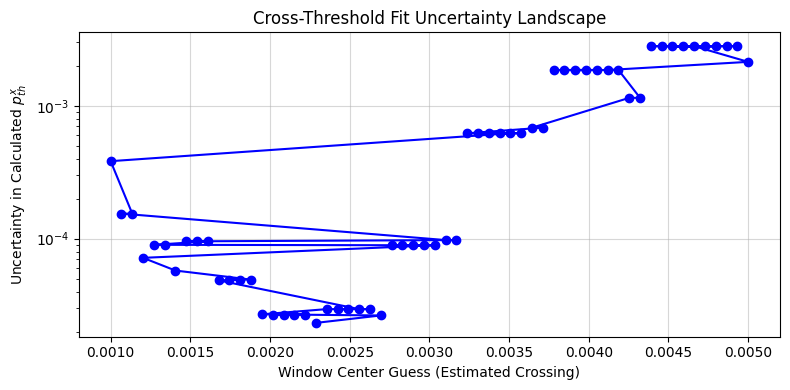

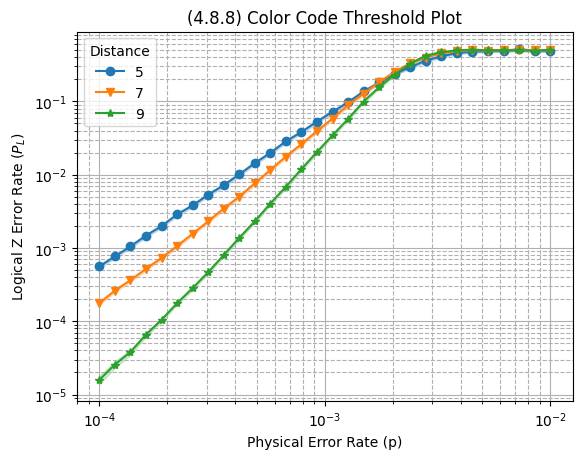


--- Calculating Scaling Threshold ---
p*_th (Scaling): 0.0018757 ± 0.0000077
c = 0.20673
alpha = 0.64339 +/- 0.00067

--- Calculating Cross Threshold ---
Using 12 data points for cross-threshold fit...
p^x_th (Cross): 0.0020164 ± 0.0000233
v_0 (Crit Exp): 1.34159 ± 0.09245


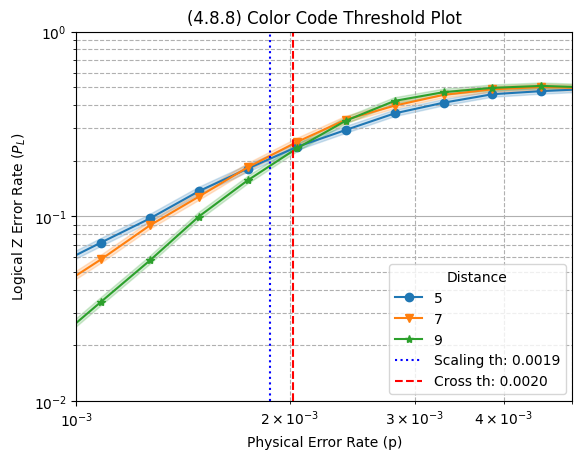

In [55]:
path = "final_report_488_CC_ZL_data.csv"
savefile = "ImplCCThresholdPlot_488_Final_ZL.png"
savefile2 = "ImplCCThresholdPlot_488_Final_ZL_Zoomed.png"
analyze_and_plot(path, savefile, 'Z', 0.0023)
analyze_and_plot_mini(path, savefile2, 'Z', 0.0023)


--- Sweeping for Optimal Crossing Point (0.001 to 0.005) ---

--- Sweep Complete ---
Optimal Data Window Centered At: 0.003644
Calculated p^x_th (Cross):       0.0030661 ± 0.0000305
Calculated v_0 (Crit Exp):       0.92459

--- Calculating Scaling Threshold ---
p*_th (Scaling): 0.0037090 ± 0.0000133
c = 0.61884
alpha = 0.69631 +/- 0.00059

--- Calculating Cross Threshold ---
Using 9 data points for cross-threshold fit...
p^x_th (Cross): 0.0030836 ± 0.0000369
v_0 (Crit Exp): 1.01994 ± 0.10216


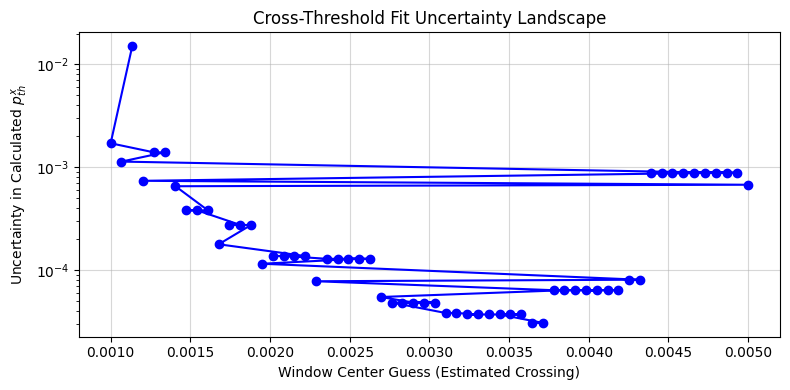

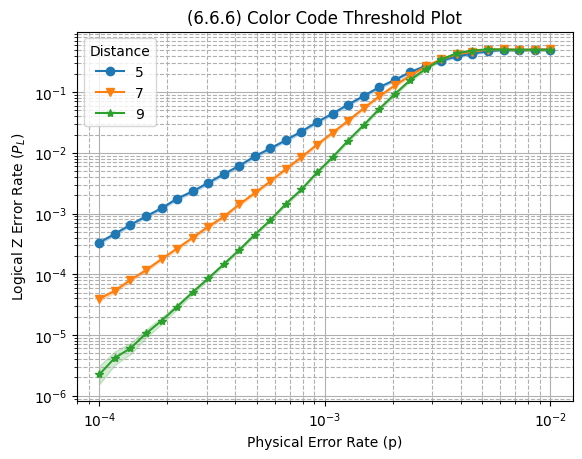


--- Calculating Scaling Threshold ---
p*_th (Scaling): 0.0037090 ± 0.0000133
c = 0.61884
alpha = 0.69631 +/- 0.00059

--- Calculating Cross Threshold ---
Using 9 data points for cross-threshold fit...
p^x_th (Cross): 0.0030836 ± 0.0000369
v_0 (Crit Exp): 1.01994 ± 0.10216


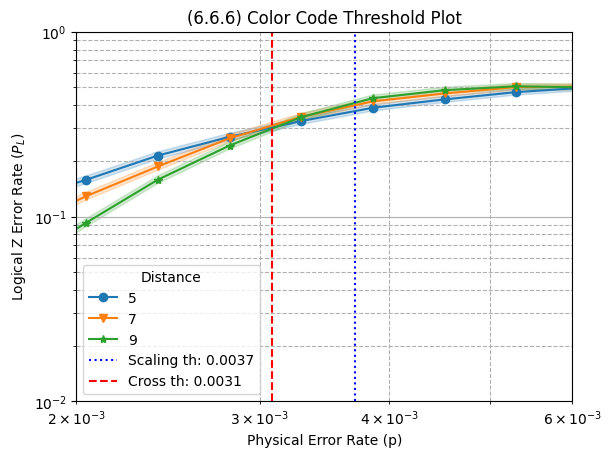

In [63]:
path = "final_report_666_CC_ZL_data_2.csv"
savefile = "ImplCCThresholdPlot_666_Final_ZL.png"
savefile2 = "ImplCCThresholdPlot_666_Final_ZL_Zoomed.png"
analyze_and_plot(path, savefile,'Z', 0.0036)
analyze_and_plot_mini(path, savefile2,'Z',0.0036)


--- Sweeping for Optimal Crossing Point (0.001 to 0.005) ---

--- Sweep Complete ---
Optimal Data Window Centered At: 0.003644
Calculated p^x_th (Cross):       0.0030258 ± 0.0000346
Calculated v_0 (Crit Exp):       1.07973

--- Calculating Scaling Threshold ---
p*_th (Scaling): 0.0037307 ± 0.0000134
c = 0.61973
alpha = 0.69444 +/- 0.00059

--- Calculating Cross Threshold ---
Using 9 data points for cross-threshold fit...
p^x_th (Cross): 0.0030333 ± 0.0000387
v_0 (Crit Exp): 1.12984 ± 0.12534


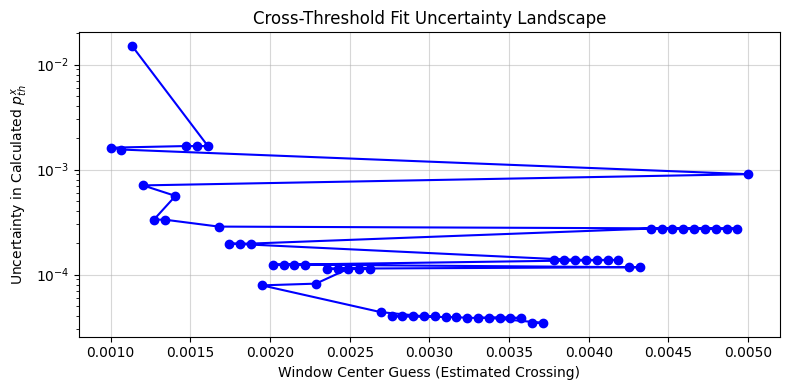

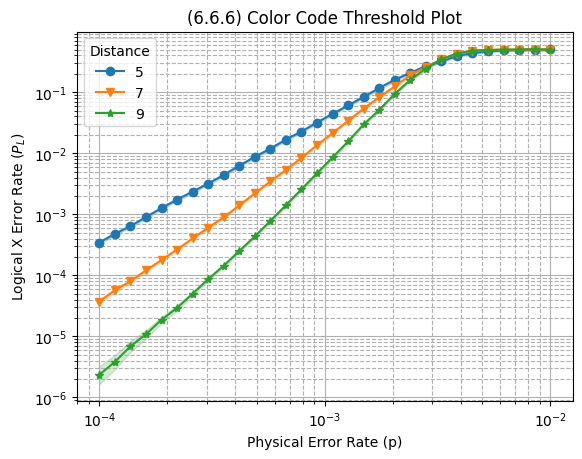


--- Calculating Scaling Threshold ---
p*_th (Scaling): 0.0037307 ± 0.0000134
c = 0.61973
alpha = 0.69444 +/- 0.00059

--- Calculating Cross Threshold ---
Using 9 data points for cross-threshold fit...
p^x_th (Cross): 0.0030333 ± 0.0000387
v_0 (Crit Exp): 1.12984 ± 0.12534


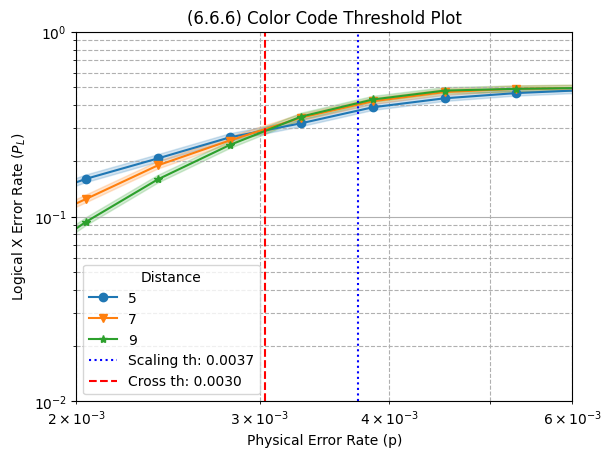

In [64]:
path = "final_report_666_CC_XL_data_2.csv"
savefile = "ImplCCThresholdPlot_666_Final_XL.png"
savefile2 = "ImplCCThresholdPlot_666_Final_XL_Zoomed.png"
analyze_and_plot(path, savefile,'X',0.0036)
analyze_and_plot_mini(path, savefile2,'X',0.0036)

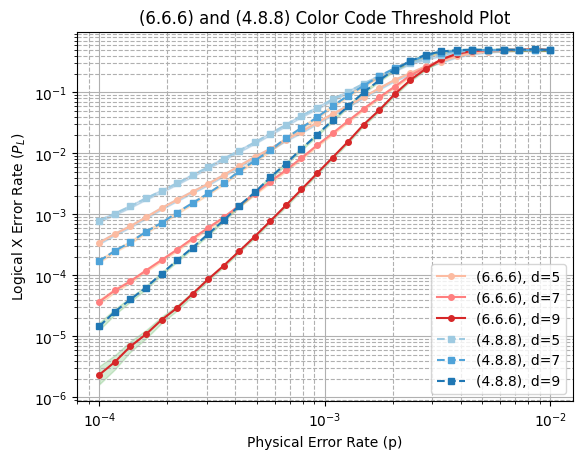

In [69]:
def analyze_and_plot(paths, labels, savefile, basis):
    fig, ax = plt.subplots()

    linestyles = ['-', '--']
    markers = ['o', 's']

    palettes = [
        ['#fcbba1', '#ff7f7f','#d62728' ], #reddish palette
        ['#9ecae1', '#4fa3d9','#1f77b4'],
        
    ]

    for i, (path, label) in enumerate(zip(paths, labels)):
        with open(path, "r") as f:
            samples = sinter.stats_from_csv_files(f)

        n_before = len(ax.lines)

        sinter.plot_error_rate(
            ax=ax,
            stats=samples,
            x_func=lambda stats: stats.json_metadata['p'],
            group_func=lambda stats: stats.json_metadata['d'],
            failure_units_per_shot_func=lambda stats: 1,
        )

        new_lines = ax.lines[n_before:]

        for j, line in enumerate(new_lines):
            color = palettes[i][j % len(palettes[i])]
            line.set_color(color)
            line.set_linestyle(linestyles[i])
            line.set_marker(markers[i])

            line.set_markersize(4)

            line.set_label(f"{label}, d={line.get_label()}")

    ax.loglog()
    ax.set_title(f"(6.6.6) and (4.8.8) Color Code Threshold Plot")
    ax.set_xlabel("Physical Error Rate (p)")
    ax.set_ylabel(f"Logical {basis} Error Rate ($P_L$)")
    ax.grid(which='major', linestyle='-')
    ax.grid(which='minor', linestyle='--')

    ax.legend()
    plt.savefig(savefile)
    plt.show()

analyze_and_plot(
    paths=["final_report_666_CC_XL_data_2.csv", "final_report_488_CC_XL_data.csv"],
    labels=["(6.6.6)", "(4.8.8)"],
    savefile="X_Comparison_Threshold_Plot.png",
    basis="X"
)

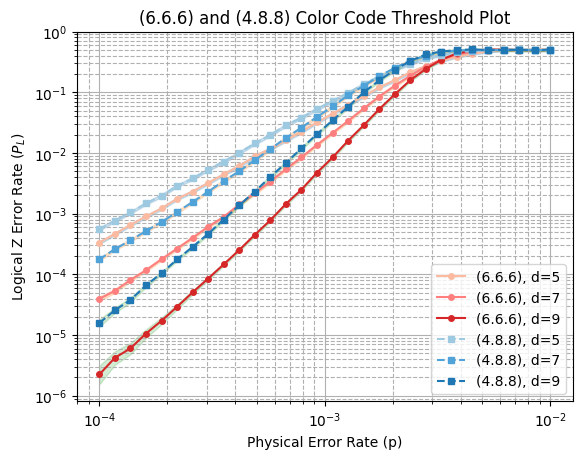

In [70]:
analyze_and_plot(
    paths=["final_report_666_CC_ZL_data_2.csv", "final_report_488_CC_ZL_data.csv"],
    labels=["(6.6.6)", "(4.8.8)"],
    savefile="Z_Comparison_Threshold_Plot.png",
    basis="Z"
)